In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
import torch
import sys
import os
import deepwave
import torch.nn.functional as F
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
freq = 6
dt = 0.004
nt = int(4 / dt) 
peak_time = 2
tlist = np.arange(0, nt, dtype=np.float32)*dt
ricker = deepwave.wavelets.ricker(freq, nt, dt, peak_time)

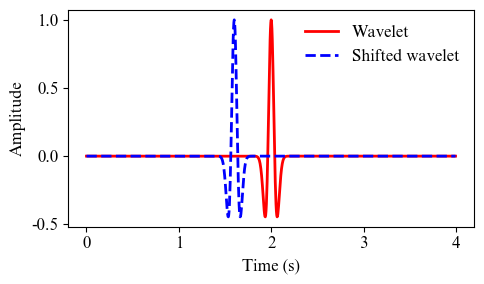

In [3]:
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.family'] = 'Times New Roman Cyr'
plt.rcParams['font.size'] = 12

ricker       = np.roll(ricker,0)
shift_ricker = np.roll(ricker,-100)

plt.figure(figsize=(5,3))
plt.plot(tlist,ricker       ,c='r',linestyle="-"    ,label="Wavelet", linewidth=2)
plt.plot(tlist,1*shift_ricker ,c='b',linestyle="--"   ,label="Shifted wavelet", linewidth=2)
plt.legend(fontsize=12)
plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Amplitude",fontsize=12)
plt.tick_params(labelsize=12)
plt.legend(frameon=False) 
plt.tight_layout()
# plt.savefig("result/wavelet.jpg", bbox_inches='tight', pad_inches=0.1, dpi=300)
# plt.show()

In [4]:
def normalize(data):
    if isinstance(data,list):
        data = np.array(data)
    res = (data - data.min())/(data.max() - data.min())
    # res = data / data.max()
    return res

In [5]:
x_shift = np.arange(-100,100,1)

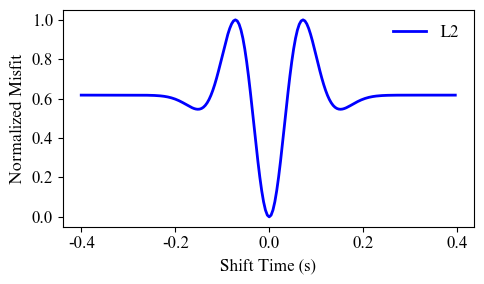

In [6]:
loss_fn = torch.nn.MSELoss()

ricker_tensor = torch.from_numpy(ricker)
ricker_tensor = ricker_tensor.reshape(1,-1,1).expand(-1, -1, 10)
L2_loss = []
for i in x_shift:
    shift_ricker = np.roll(ricker,i)
    shift_ricker_tensor = torch.from_numpy(0.5*shift_ricker)
    shift_ricker_tensor = shift_ricker_tensor.reshape(1,-1,1).expand(-1, -1, 10)
    loss = loss_fn.forward(ricker_tensor,shift_ricker_tensor)
    L2_loss.append(loss.detach().numpy())

plt.figure(figsize = (5,3))
plt.plot(x_shift*dt,normalize(L2_loss)           ,c='blue' ,label="L2", linewidth=2, linestyle='-')
plt.legend(fontsize=12, frameon=False)
plt.xlabel("Shift Time (s)",fontsize=12)
plt.ylabel("Normalized Misfit",fontsize=12)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

In [7]:
class Misfit_M_SSIM(nn.Module):
    def __init__(self, gaussian_sigmas=[0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0],
                 data_range = 1.0,
                 K=(0.01, 0.03),
                 alpha=1,
                 ct=0,
                 compensation=1):
        super(Misfit_M_SSIM, self).__init__()
        self.C1 = (K[0] * data_range) ** 2
        self.C2 = (K[1] * data_range) ** 2
        self.ct = ct
        size = int(4 * gaussian_sigmas[-1] + 1)
        self.pad = int(size / 2 * gaussian_sigmas[-1])
        self.alpha = alpha
        self.compensation=compensation
        filter_size = int(size * gaussian_sigmas[-1] + 1)

        self.pad = int(2 * gaussian_sigmas[-1])
        filter_size = int(4 * gaussian_sigmas[-1] + 1)
        
        # Create the Gaussian masks for convolution
        g_masks = torch.zeros((len(gaussian_sigmas), 1, filter_size, filter_size))
        for idx, sigma in enumerate(gaussian_sigmas):
            g_masks[idx, 0, :, :] = self._fspecial_gauss_2d(filter_size, sigma)
        
        self.g_masks = g_masks

    def _fspecial_gauss_1d(self, size, sigma):
        """Create 1-D gauss kernel"""
        coords = torch.arange(size).to(dtype=torch.float)
        coords -= size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g /= g.sum()
        return g.reshape(-1)

    def _fspecial_gauss_2d(self, size, sigma):
        """Create 2-D gauss kernel"""
        gaussian_vec = self._fspecial_gauss_1d(size, sigma)
        return torch.outer(gaussian_vec, gaussian_vec)
    def mean_filter(self,x, window_size=3):
    	kernel = torch.ones(1, 1, window_size, window_size) / (window_size ** 2)
    	kernel = kernel.to(x.device)
    	return F.conv2d(x, kernel, padding=window_size//2)

    def forward(self, obs, syn):

        
        obs = self.alpha  * obs.unsqueeze(1) 
        syn = self.alpha  * syn.unsqueeze(1)      
      
        self.g_masks = self.g_masks.to(syn.device)
               
        # Apply 2D convolution with Gaussian kernels to get the necessary statistics
        mux = F.conv2d(obs, self.g_masks, groups=1, padding=self.pad)
        muy = F.conv2d(syn, self.g_masks, groups=1, padding=self.pad)

        mux2 = mux * mux
        muy2 = muy * muy
        muxy = mux * muy

        sigmax2 = F.conv2d(obs * obs, self.g_masks, groups=1, padding=self.pad) - mux2
        sigmay2 = F.conv2d(syn * syn, self.g_masks, groups=1, padding=self.pad) - muy2
        sigmaxy = F.conv2d(obs * syn, self.g_masks, groups=1, padding=self.pad) - muxy
        sigmax = torch.sqrt(torch.clamp(sigmax2, min=1e-10))
        sigmay = torch.sqrt(torch.clamp(sigmay2, min=1e-10))

        # l, c, s in MS-SSIM
        L  = (2 * muxy    + self.C1) / (mux2    + muy2    + self.C1) 
        contrast = self.ct * torch.sqrt(torch.clamp(sigmax2 * sigmay2, min=1e-20))
        C = (2 * sigmax * sigmay + self.C2) / (sigmax2 + sigmay2 + self.C2 + contrast)
        S = (2 * sigmaxy + self.C2) / (2 * sigmax * sigmay + self.C2)  
        T = L*C*S

        loss_ms_ssim = torch.mean(-T)
            
        # loss
        loss_mix = self.compensation * loss_ms_ssim
        return loss_mix.mean()

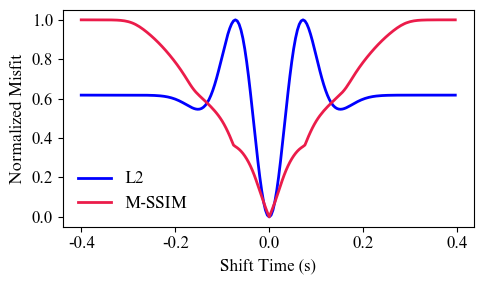

In [8]:
loss_fn = Misfit_M_SSIM(gaussian_sigmas=[0.5,1,2],ct=2)

ricker_tensor = torch.from_numpy(ricker)
ricker_tensor = ricker_tensor.reshape(1,-1,1).expand(-1, -1, 2)
MS_loss = []
for i in x_shift:
    shift_ricker = np.roll(ricker*1,i)
    shift_ricker_tensor = torch.from_numpy(0.5*shift_ricker)
    shift_ricker_tensor = shift_ricker_tensor.reshape(1,-1,1).expand(-1, -1, 2)
    loss = loss_fn.forward(ricker_tensor,shift_ricker_tensor)
    MS_loss.append(loss.detach().numpy())

plt.figure(figsize = (5,3))
plt.plot(x_shift*dt,normalize(L2_loss)           ,c='blue' ,label="L2", linewidth=2, linestyle='-')
plt.plot(x_shift*dt,normalize(MS_loss)           ,c='#EB1C4A',label="M-SSIM", linewidth=2, linestyle='-')
plt.legend(fontsize=12, frameon=False)
plt.xlabel("Shift Time (s)",fontsize=12)
plt.ylabel("Normalized Misfit",fontsize=12)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()